# Sub-daily sap flow variability as a tree stress signal: SLOPE and AREA of the diurnal SF–VPD hysteresis

Reproduction of the core metrics from:
> Schackow, A. T., Steele-Dunne, S. C., Milodowski, D. T., Limousin, J.-M., and Bastos, A.:
> **Detection of tree stress from sub-daily sap flow variability**, *Biogeosciences*, 23(10), 3365–3386, 2026.
> https://doi.org/10.5194/bg-23-3365-2026 (CC BY 4.0)

**Author code** (pinned): https://github.com/aschackow-hub/hysteresis_SF-VPD , tag `v1.0.0`,
commit `1e8b4db6bd1ab0d28a53764a7ac5fd300fe7824b` (also archived as Zenodo record 19224230, CC BY 4.0).
The metric functions below are copied verbatim from `scripts/util.py` of that commit.

**Scope (partial demonstration).** From the SAPFLUXNET database v0.1.5 we load the paper's three
focal sites — FRA_PUE (Mediterranean holm oak, France), GUF_GUY_GUY (tropical rainforest, French Guiana)
and RUS_POG_VAR (boreal forest-steppe, Russia) — compute the tree-averaged hourly sap flow (SF) and
vapour pressure deficit (VPD), and derive the two daily hysteresis metrics of §2.2:
**SLOPE** (regression slope of the morning branch of the SF–VPD loop, between the times of minimum VPD
and maximum SF) and **AREA** (enclosed polygon area of the diurnal loop). We then replicate the
focal-site seasonal cycles (Fig. 3 style) and the sampling-rate sensitivity experiment (§3.3, Fig. 7 style).

**Out of scope:** the 202-site selection screen, growing-season/daylength filtering, the 15-site
correlation and extreme-clusters analyses (Figs. 4–6), the site map, and the microwave/VOD discussion.

**Execution status:** this notebook was executed top-to-bottom on a fresh Google Colab **CPU** runtime
(2026-10-08); all outputs shown are from that run. No GPU is used anywhere in the method.
Japanese explanations follow each section heading. 日本語の説明を各節に付けています。

## Runtime selection and how to run / ランタイムの選択と実行方法

**Select Runtime → Change runtime type → CPU (Standard)** — the method is pandas/scipy/shapely
time-series analysis; a GPU would not change anything. Then **Runtime → Run all**.

Expected cost (measured on the validation run, CPU standard shape): roughly 10–20 minutes total,
dominated by the selective download of the three focal sites' CSVs (~50–150 MB) from the 3.24 GB
SAPFLUXNET archive via HTTP byte ranges, plus the per-day metric loops.

**実行方法:** 「ランタイム」→「ランタイムのタイプを変更」→**CPU** を選択してから「ランタイム」→「すべてのセルを実行」してください。
GPU は不要です。検証時の合計所要時間は約 10〜20 分（ダウンロード数十〜百数十 MB と日ごとの指標計算が主体）です。

In [ ]:
import sys
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import shapely

print("python", sys.version.split()[0])
for mod in (np, pd, scipy, shapely, gpd, plt):
    print(mod.__name__, getattr(mod, "__version__", "?"))

python 3.13.16
numpy 2.1.3
pandas 2.2.3
scipy 1.16.3
shapely 2.1.2
geopandas 1.2.0
matplotlib.pyplot ?


## Data provenance / データの入手元

SAPFLUXNET v0.1.5 (the version the author README requires) is the version record
**Zenodo 3971689** (concept DOI 10.5281/zenodo.2530798), file `0.1.5.zip`
(3,241,703,824 bytes, MD5 `9ad64ee8a8c0d361d6be8218656b1624`, CC BY 4.0).
Citation: Poyatos, R. et al., *SAPFLUXNET: a global database of sap flow measurements*.

Because that version is distributed as a single monolithic ZIP, the notebook below first tries a
**partial download**: it reads the ZIP central directory over HTTP byte ranges and fetches only the
per-site CSVs of the three focal sites (tens of MB). If range requests are unavailable, it falls back
to streaming the full archive with an MD5 check (slow: observed ≈0.6 MiB/s from Colab ⇒ ~1.5 h).

**データの出所:** SAPFLUXNET v0.1.5（Zenodo レコード 3971689、CC BY 4.0）。単一の 3.24 GB ZIP で配布されるため、
まず HTTP レンジ要求で目次だけを読み、焦点 3 サイトの CSV だけを部分ダウンロードします。レンジ要求が使えない
場合は全アーカイブのダウンロード（MD5 検証付き）にフォールバックします。

In [ ]:
import json
import urllib.request

RECORD_URL = "https://zenodo.org/api/records/3971689"  # SAPFLUXNET v0.1.5 version record
with urllib.request.urlopen(RECORD_URL, timeout=120) as r:
    record = json.load(r)

meta = record["metadata"]
print("title:", meta["title"])
print("version:", meta["version"], "| license:", meta["license"]["id"],
      "| published:", meta["publication_date"])
for f in record["files"]:
    print("file:", f["key"], "| size:", f["size"], "| md5:", f["checksum"])
    ZIP_URL = f["links"]["self"]

title: SAPFLUXNET: A global database of sap flow measurements
version: 0.1.5 | license: cc-by-4.0 | published: 2020-08-04
file: 0.1.5.zip | size: 3241703824 | md5: md5:9ad64ee8a8c0d361d6be8218656b1624


### Remote-ZIP reader

Helper functions: an HTTP **byte-range GET** with bounded retries, a parser for the ZIP
**central directory** (file names, sizes, CRC32, local-header offsets), and a member
extractor that downloads only the compressed bytes of one member, inflates them, and
verifies length + CRC32 before writing to disk. All data stays under `/content`.

**説明:** HTTP レンジ要求で ZIP の中央ディレクトリを読み、必要なメンバーの圧縮バイトだけを取得・展開し、
サイズと CRC32 を検証してから `/content` に保存します。

In [ ]:
import struct
import time
import zlib
import zipfile
import urllib.request
from pathlib import Path

DATA_DIR = Path("/content/sapfluxnet")
DATA_DIR.mkdir(exist_ok=True)


def ranged_get(url, start, length, tries=3):
    last = None
    for _ in range(tries):
        try:
            req = urllib.request.Request(url, headers={"Range": f"bytes={start}-{start + length - 1}"})
            with urllib.request.urlopen(req, timeout=300) as r:
                return r.read(), r.status
        except Exception as exc:  # bounded retry for transient network errors
            last = exc
            time.sleep(2)
    raise last


def parse_central_directory(url, total_size):
    # ZIP end-of-central-directory sits in the last 64 KiB; the central directory
    # lists every member with sizes, CRC32 and its absolute offset.
    tail, _ = ranged_get(url, total_size - 65536, 65536)
    i = tail.rfind(b"PK\x05\x06")
    assert i >= 0, "EOCD not found"
    cd_size, cd_ofs = struct.unpack("<II", tail[i + 12:i + 20])
    cd, _ = ranged_get(url, cd_ofs, cd_size)
    entries, p = [], 0
    while p + 46 <= len(cd) and cd[p:p + 4] == b"PK\x01\x02":
        n, e, c = struct.unpack("<HHH", cd[p + 28:p + 34])
        csize, usize = struct.unpack("<II", cd[p + 20:p + 28])
        crc = struct.unpack("<I", cd[p + 16:p + 20])[0]
        lho = struct.unpack("<I", cd[p + 42:p + 46])[0]
        method = struct.unpack("<H", cd[p + 10:p + 12])[0]
        entries.append(dict(name=cd[p + 46:p + 46 + n].decode(), csize=csize,
                            usize=usize, lho=lho, method=method, crc=crc))
        p += 46 + n + e + c
    return entries


def extract_member(url, entry, dest):
    # fetch the local file header to learn name/extra lengths, then the member bytes
    head, _ = ranged_get(url, entry["lho"], 30)
    n, e = struct.unpack("<HH", head[26:30])
    data_ofs = entry["lho"] + 30 + n + e
    payload, _ = ranged_get(url, data_ofs, entry["csize"])
    raw = payload if entry["method"] == 0 else zlib.decompressobj(-15).decompress(payload)
    assert len(raw) == entry["usize"], f"size mismatch: {entry['name']}"
    assert zlib.crc32(raw) == entry["crc"], f"CRC32 mismatch: {entry['name']}"
    Path(dest).write_bytes(raw)
    return len(raw)

### Select and extract the focal-site CSVs / 焦点サイトの CSV を抽出

The paper's focal sites are `FOCUS_SITES = ["FRA_PUE", "GUF_GUY_GUY", "RUS_POG_VAR"]`
(`scripts/config.py`, line 14 of the pinned commit). We extract their plant-level
`*_sapf_data.csv`, `*_env_data.csv` and the small `*_site_md.csv` / `*_plant_md.csv` /
`*_stand_md.csv` metadata files. Every member is CRC32-verified against the archive.

**説明:** 論文の焦点 3 サイトについて、植物レベルの樹液流・環境 CSV と小型のメタデータ CSV だけを
アーカイブから取り出します。各ファイルは CRC32 で検証されます。

In [ ]:
FOCUS_SITES = ["FRA_PUE", "GUF_GUY_GUY", "RUS_POG_VAR"]
SUFFIXES = ("_sapf_data.csv", "_env_data.csv", "_site_md.csv", "_plant_md.csv", "_stand_md.csv")

entries = parse_central_directory(ZIP_URL, 3_241_703_824)
print("zip members:", len(entries))
wanted = [e for e in entries
          if e["name"].startswith("0.1.5/csv/plant/")
          and e["name"].endswith(SUFFIXES)
          and any(s in e["name"] for s in FOCUS_SITES)]
print("selected:", len(wanted), "files,",
      sum(e["csize"] for e in wanted) / 1e6, "MB compressed")
for e in wanted:
    print(" ", e["name"], e["usize"], "bytes uncompressed")

zip members: 3992
selected: 15 files, 26.927615 MB compressed
  0.1.5/csv/plant/RUS_POG_VAR_stand_md.csv 363 bytes uncompressed
  0.1.5/csv/plant/RUS_POG_VAR_env_data.csv 9489950 bytes uncompressed
  0.1.5/csv/plant/FRA_PUE_site_md.csv 665 bytes uncompressed
  0.1.5/csv/plant/FRA_PUE_env_data.csv 30929261 bytes uncompressed
  0.1.5/csv/plant/GUF_GUY_GUY_site_md.csv 550 bytes uncompressed
  0.1.5/csv/plant/RUS_POG_VAR_sapf_data.csv 5737111 bytes uncompressed
  0.1.5/csv/plant/GUF_GUY_GUY_sapf_data.csv 4074787 bytes uncompressed
  0.1.5/csv/plant/FRA_PUE_stand_md.csv 516 bytes uncompressed
  0.1.5/csv/plant/GUF_GUY_GUY_stand_md.csv 432 bytes uncompressed
  0.1.5/csv/plant/GUF_GUY_GUY_plant_md.csv 2002 bytes uncompressed
  0.1.5/csv/plant/RUS_POG_VAR_site_md.csv 951 bytes uncompressed
  0.1.5/csv/plant/GUF_GUY_GUY_env_data.csv 4197982 bytes uncompressed
  0.1.5/csv/plant/RUS_POG_VAR_plant_md.csv 2191 bytes uncompressed
  0.1.5/csv/plant/FRA_PUE_plant_md.csv 5967 bytes uncompressed
  0.1.5

Run the selective extraction. If any range request fails (proxy/no-Range environment),
fall back to a full, MD5-verified download of the archive and extract the same members.

**説明:** 選択抽出を実行します。レンジ要求が失敗した場合は、MD5 検証付きでアーカイブ全体を
ダウンロードするフォールバックに切り替えます（時間がかかります）。

In [ ]:
def full_download_fallback(dest_zip="/content/0.1.5.zip"):
    import hashlib
    import shutil
    expected_md5 = "9ad64ee8a8c0d361d6be8218656b1624"
    print("Streaming full 3.24 GB archive (slow; ~1-2 h on a 0.6 MiB/s link) ...", flush=True)
    h, n = hashlib.md5(), 0
    with urllib.request.urlopen(ZIP_URL, timeout=600) as r, open(dest_zip, "wb") as out:
        while True:
            chunk = r.read(1 << 22)
            if not chunk:
                break
            out.write(chunk)
            h.update(chunk)
            n += len(chunk)
            if n % (256 << 20) < len(chunk):
                print(f"  {n/1e9:.2f} GB", flush=True)
    assert n == 3_241_703_824 and h.hexdigest() == expected_md5, "download verification failed"
    with zipfile.ZipFile(dest_zip) as zf:
        for e in wanted:
            extracted = zf.extract(e["name"], path="/content/_full")
            shutil.copy(extracted, DATA_DIR / Path(e["name"]).name)
    print("fallback extraction done")


t0 = time.time()
try:
    for e in wanted:
        dest = DATA_DIR / Path(e["name"]).name
        size = extract_member(ZIP_URL, e, dest)
        print(f"extracted {dest.name}: {size} bytes (CRC32 ok)", flush=True)
except Exception as exc:
    print("Partial ranged extraction failed:", repr(exc))
    full_download_fallback()
print(f"data ready in {time.time() - t0:.0f} s")

extracted RUS_POG_VAR_stand_md.csv: 363 bytes (CRC32 ok)


extracted RUS_POG_VAR_env_data.csv: 9489950 bytes (CRC32 ok)


extracted FRA_PUE_site_md.csv: 665 bytes (CRC32 ok)


extracted FRA_PUE_env_data.csv: 30929261 bytes (CRC32 ok)


extracted GUF_GUY_GUY_site_md.csv: 550 bytes (CRC32 ok)


...

extracted GUF_GUY_GUY_env_data.csv: 4197982 bytes (CRC32 ok)


extracted RUS_POG_VAR_plant_md.csv: 2191 bytes (CRC32 ok)


extracted FRA_PUE_plant_md.csv: 5967 bytes (CRC32 ok)


extracted FRA_PUE_sapf_data.csv: 60319909 bytes (CRC32 ok)


data ready in 40 s


## Site context / サイト概要

Show the small site/plant metadata files extracted above (biome, species) so the
sample is identifiable. These are read directly from the verified CSVs.

**説明:** 抽出したメタデータ CSV からサイトのバイオームや種情報を表示し、対象サイトを確認します。

In [ ]:
for site in FOCUS_SITES:
    site_md = pd.read_csv(DATA_DIR / f"{site}_site_md.csv")
    cols = [c for c in ("si_lat", "si_long", "si_biome", "si_mat", "si_map") if c in site_md.columns]
    print(f"--- {site}")
    print(site_md[cols].iloc[0].to_string())
    plant_md = pd.read_csv(DATA_DIR / f"{site}_plant_md.csv")
    if "pl_species" in plant_md.columns:
        print("species:", sorted(plant_md["pl_species"].dropna().unique())[:6], "...")

--- FRA_PUE
si_lat               43.741389
si_long               3.595833
si_biome    Woodland/Shrubland
si_mat               13.796654
si_map             1022.974281
species: ['Quercus ilex'] ...
--- GUF_GUY_GUY
si_lat                  5.278772
si_long               -52.924863
si_biome    Tropical rain forest
si_mat                 26.145253
si_map               2706.433926
species: ['Goupia glabra', 'Iryanthera sagotiana', 'Licania membranacea', 'Oxandra asbeckii', 'Sloanea sp', 'Vacapoua americana'] ...
--- RUS_POG_VAR
si_lat                   56.36
si_long                  92.95
si_biome    Woodland/Shrubland
si_mat                1.093693
si_map              410.415885
species: ['Larix gmelinii', 'Larix sibirica Ledeb.', 'Pinus sibirica'] ...


## Author function: `get_subdaily` — hourly tree-mean SF and VPD

Copied **verbatim** from `scripts/util.py` (lines 18–43) of commit `1e8b4db6`: the tree sensor
columns (everything after the two timestamp columns) are averaged and divided by 1000
("convert to litres (SAPFLUXNET convention)"), the VPD column of the environmental file is joined
on the solar timestamp, sentinel value −9999999 becomes NaN, negative values are masked, and the
half-hourly data are resampled to hourly means — the input resolution of all hysteresis metrics.

**説明:** 著者コード `scripts/util.py`（18–43 行目）をそのままコピーした `get_subdaily` です。
樹木センサー列の平均を 1000 で割ってリットル換算し、太陽時タイムスタンプで VPD と結合、
−9999999 を欠測、負値をマスクしてから hourly に再サンプリングします。

In [ ]:
def get_subdaily(sap, env):
    # load sap flow data
    df_sap = pd.read_csv(sap)

    # average across all tree sensors, convert to litres (SAPFLUXNET convention)
    trees = df_sap.columns[2:]
    df_sap["SF"] = df_sap[trees].mean(axis=1) / 1000

    # load environmental data
    df_env = pd.read_csv(env)

    # pick the solar timestamp column
    ts_candidates = ["TIMESTAMP_solar", "solar_TIMESTAMP", "SOLAR_TIMESTAMP"]
    ts_col = next((c for c in ts_candidates if c in df_sap.columns), None)

    # combine sap flow and VPD into a single frame
    df = df_sap[["SF", ts_col]].rename(columns={ts_col: "TIMESTAMP"})
    if "vpd" in df_env.columns:
        df["VPD"] = df_env["vpd"]

    df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"])
    df.replace(-9999999, np.nan, inplace=True)
    df.set_index("TIMESTAMP", inplace=True)
    df = df.where(df >= 0)

    return df.resample("h").mean()  # hourly SF and VPD for hysteresis analysis


sapf_csv = DATA_DIR / "FRA_PUE_sapf_data.csv"
env_csv = DATA_DIR / "FRA_PUE_env_data.csv"
subdaily = get_subdaily(sapf_csv, env_csv)
print(subdaily.shape, "|", subdaily.index.min(), "->", subdaily.index.max())
subdaily.describe()

(140257, 2) | 1999-12-31 23:00:00+00:00 -> 2015-12-31 23:00:00+00:00


,SF,VPD
count,138388.000000,112452.000000
mean,0.091079,0.638275
std,0.130119,0.754381
min,0.000000,0.000000
25%,0.008083,0.094606
50%,0.030120,0.379083
75%,0.121018,0.857210
max,1.113632,6.531870


## Input preview / 入力データのプレビュー

Plot one deterministic 7-day window: the first window with at least 80 % valid hourly SF and VPD
(searched from the start of the record; no cherry-picking). Left axis: tree-mean sap flow (L h⁻¹);
right axis: VPD (kPa). This is the actual input the metrics below are computed from.

**説明:** 欠測が少ない最初の 7 日間を機械的に選んで SF（L/h）と VPD（kPa）を描画します。
季節の選別は行っていません。

preview window: 2003-01-06 00:00:00+00:00 -> 2003-01-13 00:00:00+00:00


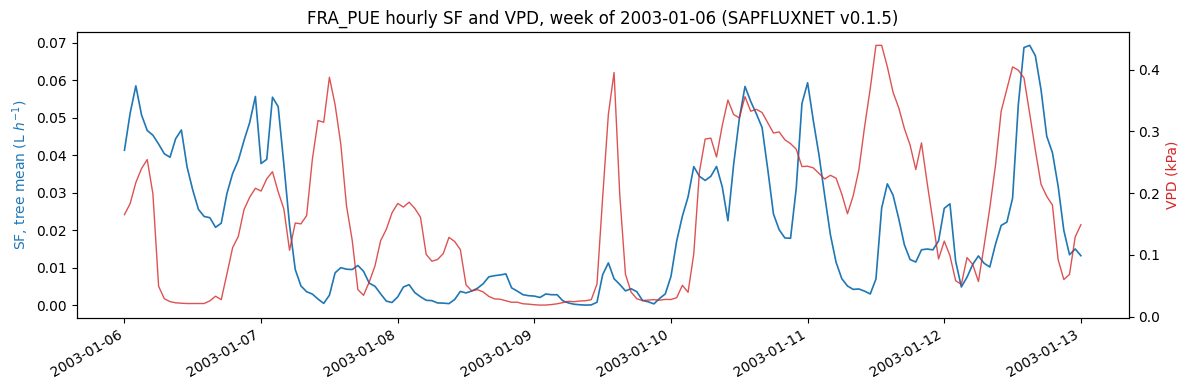

In [ ]:
valid = subdaily["VPD"].rolling(24 * 7).count()
start = valid[valid >= 0.8 * 24 * 7].index[0].normalize()
week = subdaily.loc[start:start + pd.Timedelta(days=7)]
print("preview window:", start, "->", start + pd.Timedelta(days=7))

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(week.index, week["SF"], color="tab:blue", lw=1.2)
ax1.set_ylabel("SF, tree mean (L $h^{-1}$)", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(week.index, week["VPD"], color="tab:red", lw=1.0, alpha=0.8)
ax2.set_ylabel("VPD (kPa)", color="tab:red")
ax1.set_title(f"FRA_PUE hourly SF and VPD, week of {start.date()} (SAPFLUXNET v0.1.5)")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

### Mean diurnal hysteresis loop and one example day / 平均日内ループと実例

Left: the mean diurnal SF–VPD loop (all days, grouped by hour of day, closed loop) — the shape
whose morning-branch slope and enclosed area define the two metrics. Right: the first fully
observed day, drawn as a loop in the same (VPD, SF) plane with hours annotated.

**説明:** 左は全日を時間帯で平均した SF–VPD ループ（指標の対象となる形状）、
右は最初の完全観測日のループ例です。

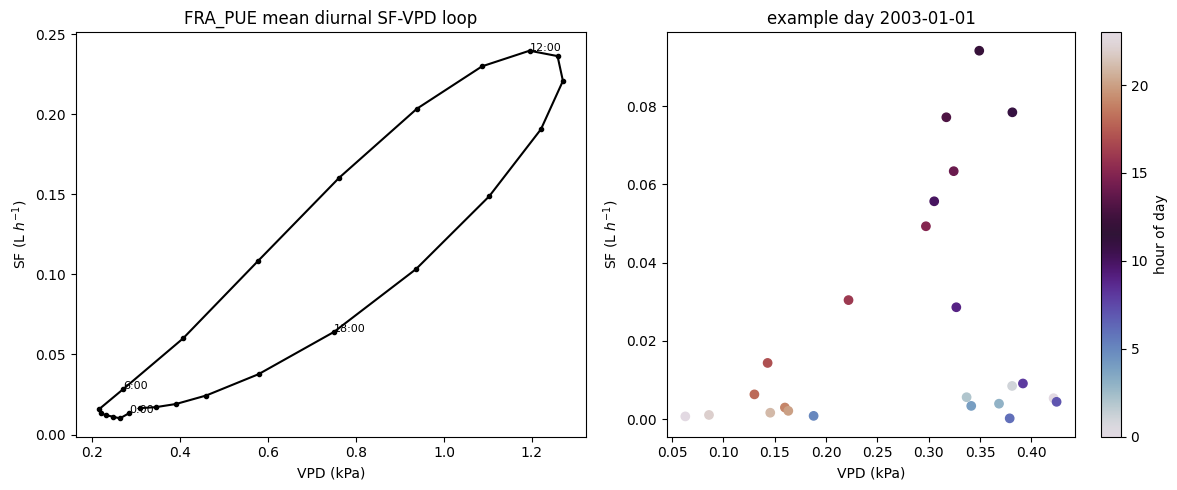

In [ ]:
profile = subdaily.groupby(subdaily.index.hour).mean()
first_day = subdaily.dropna().index[0].normalize()
day = subdaily.loc[first_day:first_day + pd.Timedelta(hours=23)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.plot(profile["VPD"], profile["SF"], "-o", ms=3, color="k")
for h in (0, 6, 12, 18):
    r = profile.loc[h]
    ax.annotate(f"{h}:00", (r["VPD"], r["SF"]), fontsize=8)
ax.set_xlabel("VPD (kPa)"); ax.set_ylabel("SF (L $h^{-1}$)")
ax.set_title("FRA_PUE mean diurnal SF-VPD loop")

ax = axes[1]
sc = ax.scatter(day["VPD"], day["SF"], c=day.index.hour, cmap="twilight")
plt.colorbar(sc, ax=ax, label="hour of day")
ax.set_xlabel("VPD (kPa)"); ax.set_ylabel("SF (L $h^{-1}$)")
ax.set_title(f"example day {first_day.date()}")
fig.tight_layout()
plt.show()

## Metric 1 — `SLOPE`: morning-branch regression / 指標 1: SLOPE（午前側の回帰勾配）

Copied verbatim from `scripts/util.py` (`get_regression` L87–97, `single_slope` L100–122,
`get_slope` L125–137). For each day: find the times of minimum VPD and maximum SF, take the
hourly points between them (the morning branch), and compute the ordinary least-squares slope
of SF on VPD via `scipy.stats.linregress`. The daily SLOPE series is the plant hydraulic
sensitivity to atmospheric demand (paper §2.2).

**説明:** 各日について VPD 最小時刻から SF 最大時刻までの「午前側」の点に線形回帰を当てはめ、
その勾配を日単位の SLOPE とします（`scipy.stats.linregress`、著者コードの逐語コピー）。

In [ ]:
from scipy.stats import linregress


def get_regression(ref, sampled):
    ref.index = sampled.index
    mask = ~np.isnan(ref) & ~np.isnan(sampled)

    if len(ref[mask]) > 1 and len(sampled[mask]) > 1 and len(set(ref[mask])) > 1:
        slope, intercept, r_value, p_value, std_err = linregress(ref[mask], sampled[mask])
        return slope, intercept, r_value, p_value, std_err  # linear regression stats

    return np.nan, np.nan, np.nan, np.nan, np.nan  # insufficient data for regression


def single_slope(vpd, sap):
    # compute the morning-branch regression slope of the SF-VPD hysteresis loop
    if not vpd.isna().all() and not sap.isna().all():
        idxv_min = vpd.idxmin()
        idxs_max = sap.idxmax()
        vpd.index = pd.to_datetime(vpd.index)
        sap.index = pd.to_datetime(sap.index)
        if not isinstance(idxv_min, str):
            morning_data = pd.concat([vpd, sap], axis=1).between_time(
                idxv_min.strftime("%H:%M"), idxs_max.strftime("%H:%M")
            )
        else:
            morning_data = pd.concat([vpd, sap], axis=1).between_time(idxv_min, idxs_max)
        x_morning = morning_data["VPD"]
        y_morning = morning_data["SF"]
        if x_morning.dropna().nunique() <= 1 or y_morning.dropna().nunique() <= 1:
            return np.nan, np.nan, np.nan, np.nan, np.nan  # too few unique values

        return get_regression(x_morning, y_morning)  # (slope, intercept, r, p, se)

    return np.nan, np.nan, np.nan, np.nan, np.nan  # all-NaN input


def get_slope(subdaily):
    # daily SLOPE: regression slope of morning SF-VPD relationship
    slopes = []
    for date in np.unique(subdaily.index.date):
        x = subdaily["VPD"].loc[str(date)]
        y = subdaily["SF"].loc[str(date)]
        reg = single_slope(x, y)[0]
        slopes.append(reg if isinstance(reg, float) else np.nan)

    slope_df = pd.DataFrame(
        {"date": pd.to_datetime(np.unique(subdaily.index.date)), "SLOPE": slopes}
    )
    return slope_df.set_index("date")  # daily time series of SLOPE

## Metric 2 — `AREA`: enclosed hysteresis area / 指標 2: AREA（ループ囲み面積）

Copied verbatim from `scripts/util.py` (`single_area` L140–154, `get_area` L157–171). For each day
the hourly (VPD, SF) points form a closed polygon; its planar area is computed through
`geopandas.GeoSeries(...).area` (shapely geometry), exactly as the authors do. Days with fewer
than three valid points yield NaN; a two-point day yields 0.0 by the author's convention.
AREA characterises the magnitude of the daily SF–VPD decoupling (paper §2.2).

**説明:** 各日の (VPD, SF) 点列を多角形とみなし、`geopandas`/shapely で囲み面積を計算します
（著者コードの逐語コピー）。有効点が 3 点未満の日は欠測になります。

In [ ]:
from shapely.geometry import Polygon


def single_area(vpd, sap):
    # enclosed area of the daily SF-VPD hysteresis loop
    mask = ~np.isnan(vpd) & ~np.isnan(sap)

    if len(vpd) == 2:
        area = 0.0
    elif len(vpd[mask]) >= 3 and len(sap[mask]) >= 3:
        vpd_list = vpd.dropna().values.tolist()
        sap_list = sap.dropna().values.tolist()
        polygon = Polygon(zip(vpd_list, sap_list))
        area = gpd.GeoSeries([polygon]).area.item()
    else:
        area = np.nan

    return area  # scalar: polygon area in VPD-SF space, or NaN if insufficient data


def get_area(subdaily):
    # daily AREA: enclosed polygon area of the SF-VPD hysteresis loop
    vpd = subdaily["VPD"]
    sap = subdaily["SF"]
    areas = []

    for date in np.unique(sap.index.date):
        x = vpd.loc[str(date)]
        y = sap.loc[str(date)]
        areas.append(single_area(x, y))

    area_df = pd.DataFrame(
        {"date": pd.to_datetime(np.unique(sap.index.date)), "AREA": areas}
    )
    return area_df.set_index("date")  # daily time series of AREA

## Sampling-rate scenarios and reference R² / サンプリング間隔のシナリオと R²

`get_resampled` (verbatim, `util.py` L77–84) subsamples the hourly frame to the paper's §3.3
scenarios: **8TPD** (3-hourly: hours 0,3,6,9,12,15,18,21), **4TPD** (6-hourly: 0,6,12,18),
**3TPDnight** (0,6,18 — noon missing) and **3TPDday** (6,12,18 — midnight missing), plus the
hourly reference. `get_correlations_to_hourly` (verbatim, L279–294) then reports the R² of each
resampled daily metric against the hourly-reference daily metric for the same site.

**説明:** 論文 §3.3 の 4 つのサンプリングシナリオ（8TPD/4TPD/3TPDnight/3TPDday）を
著者コードのまま作成し、hourly を基準とした日次指標の R² を評価します。

In [ ]:
def get_resampled(sd_data):
    # create sub-sampled versions of hourly data at different temporal resolutions
    T8PD = sd_data.iloc[sd_data.index.hour.isin([0, 3, 6, 9, 12, 15, 18, 21])]
    T4PD = sd_data.iloc[sd_data.index.hour.isin([0, 6, 12, 18])]
    T3PD_night = sd_data.iloc[sd_data.index.hour.isin([0, 6, 18])]
    T3PD_day = sd_data.iloc[sd_data.index.hour.isin([6, 12, 18])]

    return [T8PD, T4PD, T3PD_night, T3PD_day, sd_data]  # last element is hourly reference


def get_correlations_to_hourly(slopeframe, areaframe):
    # R-squared of each resampled metric against the hourly reference
    slope_coeffs = {}
    area_coeffs = {}

    for proposal in slopeframe.columns[:-1]:  # exclude "hourly" itself
        coeff_slope = get_regression(slopeframe["hourly"], slopeframe[proposal])[2] ** 2
        slope_coeffs[proposal] = coeff_slope

        coeff_area = get_regression(areaframe["hourly"], areaframe[proposal])[2] ** 2
        area_coeffs[proposal] = coeff_area

    longterm_sdf = pd.Series(slope_coeffs)
    longterm_adf = pd.Series(area_coeffs)

    return longterm_sdf, longterm_adf  # R-squared per sample rate, for SLOPE and AREA

## Compute daily SLOPE and AREA for the focal sites / 焦点サイトの日次 SLOPE・AREA を計算

For each focal site: build the hourly frame (`get_subdaily`), form the five sampling scenarios,
and compute daily SLOPE and AREA for each — exactly the author's `prepare()` path
(`scripts/main.py` L63–73). Progress is printed per scenario; the whole cell takes a few
minutes on a CPU runtime because each day is processed individually (as in the author code).

**説明:** 各焦点サイトについて hourly フレームを作り、5 つのサンプリング scenario それぞれで
日次 SLOPE・AREA を著者コードと同じ手順で計算します（数分かかります）。

In [ ]:
import time

SCENARIOS = ["8TPD", "4TPD", "3TPDnight", "3TPDday", "hourly"]
results = {}
t0 = time.time()
for site in FOCUS_SITES:
    sub = get_subdaily(DATA_DIR / f"{site}_sapf_data.csv", DATA_DIR / f"{site}_env_data.csv")
    resamplings = get_resampled(sub)
    slopes, areas = [], []
    for name, res in zip(SCENARIOS, resamplings):
        slopes.append(get_slope(res))
        areas.append(get_area(res))
        print(f"{site} {name}: {len(slopes[-1])} days", flush=True)
    slopeframe = pd.concat(slopes, axis=1)
    areaframe = pd.concat(areas, axis=1)
    slopeframe.columns = SCENARIOS
    areaframe.columns = SCENARIOS
    results[site] = dict(subdaily=sub, slopeframe=slopeframe, areaframe=areaframe)
    print(f"{site} done ({time.time() - t0:.0f} s elapsed)", flush=True)

print(f"all sites computed in {time.time() - t0:.0f} s")
results["FRA_PUE"]["slopeframe"].describe()

FRA_PUE 8TPD: 5844 days


FRA_PUE 4TPD: 5844 days


FRA_PUE 3TPDnight: 5844 days


FRA_PUE 3TPDday: 5844 days


FRA_PUE hourly: 5845 days


...

RUS_POG_VAR 3TPDday: 731 days


RUS_POG_VAR hourly: 732 days


RUS_POG_VAR done (224 s elapsed)


all sites computed in 224 s


,8TPD,4TPD,3TPDnight,3TPDday,hourly
count,4523.000000,4397.000000,3930.000000,4358.000000,4582.000000
mean,1.273282,1.611655,4.751200,1.466976,1.421228
std,19.863139,30.201634,163.527646,24.713577,26.555023
min,-83.681579,-55.080255,-48.758141,-57.904607,-75.683399
25%,0.134805,0.148246,0.047442,0.150905,0.141507
50%,0.285038,0.291648,0.095950,0.298219,0.291476
75%,0.416575,0.442044,0.172039,0.451883,0.429281
max,1101.945399,1831.919581,9994.267665,1403.065576,1619.355450


## Focal-site seasonal cycles (Fig. 3 style) / 焦点サイトの季節サイクル（Fig. 3 スタイル）

`get_seasonal` (verbatim, `util.py` L438–473) aligns each year to a common 365-day (month-day)
calendar, removing Feb 29. The panel for each site shows the across-year median (7-day centred
rolling mean) with the 25–75 % IQR band for SLOPE (blue, left scale) and AREA (black, right
scale), mirroring the author's Fig. 3 rendering; the daylength/growing-season marker lines of
the original figure are omitted (out of scope). Units follow the author's `/1000` conversion,
so SLOPE is in L h⁻¹ kPa⁻¹ and AREA in kPa·L h⁻¹.

**説明:** `get_seasonal`（逐語コピー）で各年を 365 日カレンダーに揃え、SLOPE（青）と AREA（黒）の
年間サイクルを中央値＋IQR で描画します。元図の昼長マーカーは範囲外のため省略しています。

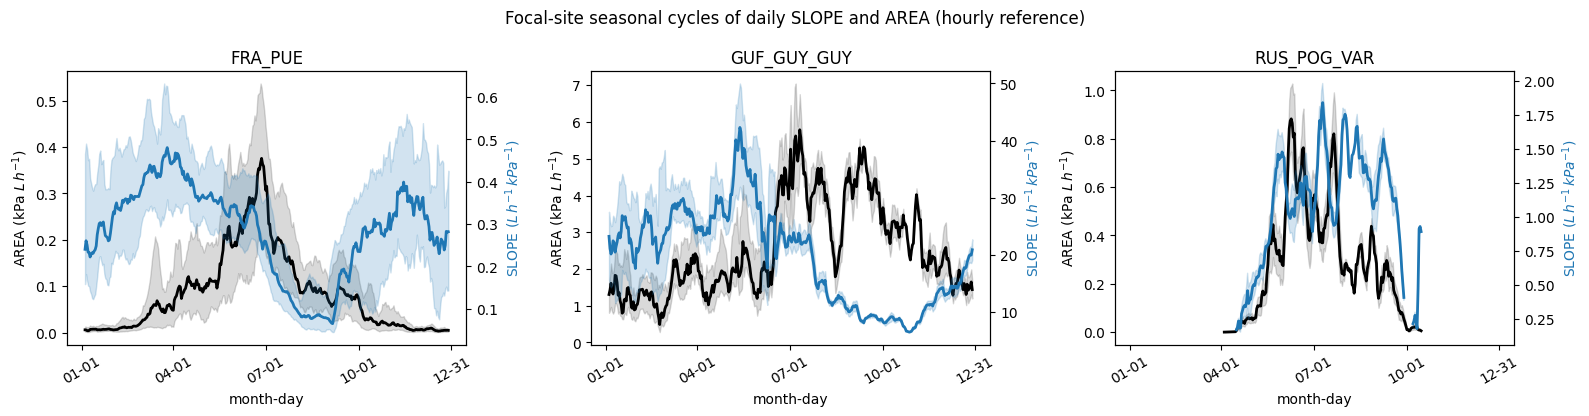

In [ ]:
def get_seasonal(slopeframe, areaframe, daily):
    # annual seasonal cycles of SLOPE and AREA, aligned to a common 365-day calendar
    slope_cycles, area_cycles = {}, {}

    for year in np.unique(daily.index.year):
        start = pd.to_datetime(f"{year}-01-01")
        end = pd.to_datetime(f"{year}-12-31")

        empty = pd.DataFrame(index=pd.date_range(start=start, end=end, freq="1d"))

        annual_slope = slopeframe["hourly"].loc[slopeframe["hourly"].index.year == year]
        annual_area = areaframe["hourly"].loc[areaframe["hourly"].index.year == year]

        # remove Feb 29 so all years have 365 rows
        annual_slope = annual_slope[~(annual_slope.index.month == 2) | (annual_slope.index.day != 29)]
        annual_area = annual_area[~(annual_area.index.month == 2) | (annual_area.index.day != 29)]
        empty = empty[~(empty.index.month == 2) | (empty.index.day != 29)]

        empty["SLOPE"] = annual_slope
        empty["AREA"] = annual_area

        slope_cycles[str(year)] = empty["SLOPE"].reset_index(drop=True)
        area_cycles[str(year)] = empty["AREA"].reset_index(drop=True)

    df_slope = pd.DataFrame.from_dict(slope_cycles)
    df_area = pd.DataFrame.from_dict(area_cycles)

    index = empty.index.strftime("%m-%d")
    df_slope.index = index
    df_area.index = index

    return df_slope, df_area  # year-columns x DOY-rows


fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True)
for ax, site in zip(axes, FOCUS_SITES):
    df_slope, df_area = get_seasonal(results[site]["slopeframe"],
                                     results[site]["areaframe"],
                                     results[site]["subdaily"].resample("D").mean())
    slope_med = df_slope.median(axis=1).rolling(7, center=True).mean()
    slope_q25 = df_slope.quantile(0.25, axis=1).rolling(7, center=True).mean()
    slope_q75 = df_slope.quantile(0.75, axis=1).rolling(7, center=True).mean()
    area_med = df_area.median(axis=1).rolling(7, center=True).mean()
    area_q25 = df_area.quantile(0.25, axis=1).rolling(7, center=True).mean()
    area_q75 = df_area.quantile(0.75, axis=1).rolling(7, center=True).mean()

    x = np.arange(len(slope_med))
    ax2 = ax.twinx()
    ax2.fill_between(x, slope_q25, slope_q75, color="#1f77b4", alpha=0.2)
    ax2.plot(x, slope_med, color="#1f77b4", lw=2, label="SLOPE")
    ax.fill_between(x, area_q25, area_q75, color="black", alpha=0.15)
    ax.plot(x, area_med, color="black", lw=2, label="AREA")
    ax.set_title(site)
    ax.set_xlabel("month-day")
    ax.set_ylabel(r"AREA (kPa $L\,h^{-1}$)", color="black")
    ax2.set_ylabel(r"SLOPE ($L\,h^{-1}\,kPa^{-1}$)", color="#1f77b4")
    ticks = [0, 90, 181, 273, 364]
    ax.set_xticks(ticks)
    ax.set_xticklabels([df_slope.index[t] for t in ticks], rotation=30)
fig.suptitle("Focal-site seasonal cycles of daily SLOPE and AREA (hourly reference)")
fig.tight_layout()
plt.show()

## Sampling-rate sensitivity (Fig. 7 style) / サンプリングレート感度（Fig. 7 スタイル）

Left: mean diurnal SF–VPD loops of FRA_PUE at each resampling scenario against the hourly
reference (grey), as in the author's `plot_rates`. Right: per-site R² of the resampled daily
metrics versus the hourly reference (`get_correlations_to_hourly`), shown as a grouped bar chart.

**説明:** 左に FRA_PUE の各サンプリング間隔での平均日内ループ（灰色は hourly 基準）、
右に hourly 基準の日次指標に対する R² をサイト別に棒グラフで示します。

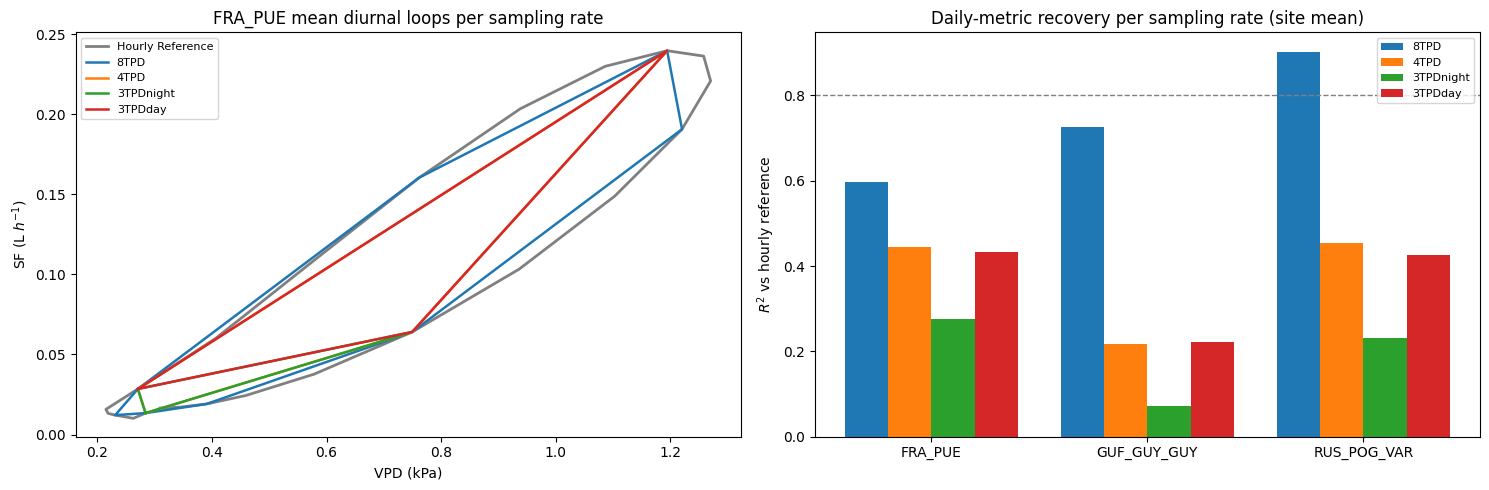

metric           AREA                                   SLOPE            \
scenario      3TPDday 3TPDnight      4TPD      8TPD   3TPDday 3TPDnight   
site                                                                      
FRA_PUE      0.849251  0.547341  0.872917  0.969204  0.018127  0.004278   
GUF_GUY_GUY  0.285854  0.040603  0.280869  0.768300  0.159077  0.103642   
RUS_POG_VAR  0.599006  0.242620  0.637187  0.889885  0.251665  0.221166   

metric                           
scenario         4TPD      8TPD  
site                             
FRA_PUE      0.018232  0.225378  
GUF_GUY_GUY  0.155586  0.684078  
RUS_POG_VAR  0.269430  0.915213

In [ ]:
fig, (ax_loops, ax_r2) = plt.subplots(1, 2, figsize=(15, 5))

sub_pue = results["FRA_PUE"]["subdaily"]
hourly_ref = sub_pue[["SF", "VPD"]].groupby(sub_pue.index.hour).mean()
ax_loops.plot(hourly_ref["VPD"], hourly_ref["SF"], color="grey", lw=2, label="Hourly Reference")
for name, res in zip(SCENARIOS[:-1], get_resampled(sub_pue)[:-1]):
    concept = res[["SF", "VPD"]].groupby(res.index.hour).mean()
    concept = pd.concat([concept, concept.iloc[[0]]])
    ax_loops.plot(concept["VPD"], concept["SF"], lw=1.8, label=name)
ax_loops.set_xlabel("VPD (kPa)"); ax_loops.set_ylabel("SF (L $h^{-1}$)")
ax_loops.set_title("FRA_PUE mean diurnal loops per sampling rate")
ax_loops.legend(fontsize=8)

r2_rows = []
for site in FOCUS_SITES:
    s_r2, a_r2 = get_correlations_to_hourly(results[site]["slopeframe"], results[site]["areaframe"])
    for scenario in SCENARIOS[:-1]:
        r2_rows.append(dict(site=site, scenario=scenario, metric="SLOPE", R2=s_r2[scenario]))
        r2_rows.append(dict(site=site, scenario=scenario, metric="AREA", R2=a_r2[scenario]))
r2_df = pd.DataFrame(r2_rows)

width = 0.2
for i, scenario in enumerate(SCENARIOS[:-1]):
    vals = [r2_df[(r2_df.site == s) & (r2_df.scenario == scenario)]["R2"].mean() for s in FOCUS_SITES]
    ax_r2.bar(np.arange(len(FOCUS_SITES)) + (i - 1.5) * width, vals, width, label=scenario)
ax_r2.axhline(0.8, color="grey", ls="--", lw=1)
ax_r2.set_xticks(np.arange(len(FOCUS_SITES)), FOCUS_SITES)
ax_r2.set_ylabel("$R^2$ vs hourly reference")
ax_r2.set_title("Daily-metric recovery per sampling rate (site mean)")
ax_r2.legend(fontsize=8)
fig.tight_layout()
plt.show()

r2_pivot = r2_df.pivot_table(index="site", columns=["metric", "scenario"], values="R2")
r2_pivot

## Export daily metrics / 日次指標のエクスポート

Write one CSV per site with the daily SLOPE/AREA under all five sampling scenarios, plus the R²
table, under `/content/sapfluxnet/` for download.

**説明:** サイトごとの日次 SLOPE/AREA（全 scenario）と R² 表を CSV として `/content/sapfluxnet/` に保存します。

In [ ]:
outdir = DATA_DIR / "outputs"
outdir.mkdir(exist_ok=True)
for site in FOCUS_SITES:
    frame = results[site]["slopeframe"].join(results[site]["areaframe"], lsuffix="_SLOPE", rsuffix="_AREA")
    frame.to_csv(outdir / f"{site}_daily_metrics.csv")
r2_df.to_csv(outdir / "samplerate_R2.csv", index=False)
print(sorted(p.name for p in outdir.iterdir()))
results["FRA_PUE"]["slopeframe"][["hourly"]].join(
    results["FRA_PUE"]["areaframe"][["hourly"]], lsuffix="_SLOPE", rsuffix="_AREA"
).head()

['FRA_PUE_daily_metrics.csv', 'GUF_GUY_GUY_daily_metrics.csv', 'RUS_POG_VAR_daily_metrics.csv', 'samplerate_R2.csv']


,hourly_SLOPE,hourly_AREA
date,,
1999-12-31,NaN,NaN
2000-01-01,NaN,NaN
2000-01-02,NaN,NaN
2000-01-03,NaN,NaN
2000-01-04,NaN,NaN


## Interpretation and comparison with the paper / 解釈と論文との比較

What to look for (paper §3.1–§3.3):
- **Seasonal cycles (Fig. 3 style):** at FRA_PUE the daily SLOPE and AREA vary seasonally; in the
  paper AREA tracks energy drivers (TAir/PPFD) at all sites, while the SLOPE–soil-moisture link
  is site dependent.
- **Sampling-rate sensitivity (§3.3):** the paper reports that AREA is well preserved at 8TPD
  (median annual R² 0.95) and still usable at 3TPDday (0.74) and 4TPD (0.76), but degrades
  strongly at 3TPDnight (0.30); SLOPE is poorly recovered at all sparse rates (median ≤ 0.5).
  The site-level R² values computed above can be compared with these statements — note our
  values are whole-series R² per site as computed by the author code
  (`get_correlations_to_hourly`), whereas the quoted paper numbers are medians over sites/years.

**Limitations of this demonstration:** three focal sites instead of the full 15-site selection;
no growing-season or daylength filtering; no extreme-cluster or correlation analyses; a one-site
(or three-site) example does not verify the paper's dataset-level statistics. The `/1000`
"convert to litres" convention of the author code is preserved, so SLOPE/AREA units are
L h⁻¹ kPa⁻¹ and kPa·L h⁻¹ respectively (the published figure axes are labelled in m³ s⁻¹).

**解釈のポイント:** AREA は 8TPD・4TPD・3TPDday でよく保たれ、正午欠落の 3TPDnight で大きく劣化します。
SLOPE はどの疎サンプリングでも復元が難しい、というのが論文 §3.3 の結論で、上の R² と比較できます。
本デモは 3 焦点サイトのみで、15 サイト選別や極端気象クラスタ分析などは範囲外です。

## References and provenance / 参照と由来

- Schackow, A. T. et al. (2026): Detection of tree stress from sub-daily sap flow variability.
  *Biogeosciences* 23(10), 3365–3386. https://doi.org/10.5194/bg-23-3365-2026 (CC BY 4.0)
- Author code: https://github.com/aschackow-hub/hysteresis_SF-VPD , tag `v1.0.0`,
  commit `1e8b4db6bd1ab0d28a53764a7ac5fd300fe7824b`; Zenodo record 19224230 (CC BY 4.0).
  Metric functions copied verbatim from `scripts/util.py`; data acquisition (remote-ZIP partial
  download) and plotting are new, notebook-specific glue.
- Data: SAPFLUXNET v0.1.5, Zenodo record 3971689 (file `0.1.5.zip`, MD5
  `9ad64ee8a8c0d361d6be8218656b1624`, CC BY 4.0). Poyatos, R. et al., SAPFLUXNET database.
- AI-assisted notebook assembly: the Colab glue (data route, plots, text) was written with AI
  assistance; the scientific functions are the authors' own code. This reproduction is not
  author-endorsed, and a three-site example does not validate the paper's full results.
- PhenoPaper investigation `p-b69eca42d55fc44cf901d348d34d6842-20261008T141938Z-1156784`
  (AI-generated, unverified) was used as prior research guidance only.